In [1]:
import pickle
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import colorednoise as cn
from scipy.signal import find_peaks
from scipy.stats import laplace
from scipy.interpolate import CubicSpline, interp1d

In [2]:
n_probes = 100
n_channels = 64
sim_flag = 'probes_dt'

top_dir = os.path.dirname(os.path.dirname(os.getcwd()))
sim_dir = os.path.join(top_dir, 'models/NEURON/NMLCL000073-NEURON/output/LFP_basal')
sim_label = f'LFP_basal-0nA-50Ex1-1x40Hz-{n_probes}x{n_channels}lp-{sim_flag}'


eap_file_path = os.path.join(sim_dir, sim_label, f'{sim_label}-simulated_eaps.pkl')
probe_file_path = os.path.join(sim_dir, sim_label, f'{sim_label}-recording_probe_locs.pkl')

In [4]:
data_df = pd.read_pickle(eap_file_path)
probes = np.array(pd.read_pickle(probe_file_path))

In [5]:
num_probes, num_channels, _ = np.shape(probes)

probe_nums = []
channel_nums = []

for i, row in data_df.iterrows():
    probe_nums.append(int(i/num_channels))
    channel_nums.append(i%num_channels)

data_df['probe_num'] = probe_nums
data_df['channel_num'] = channel_nums

In [6]:
data_df.head()

,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num
0,NMLCL000073,"[400.0000000000567, 400.0500000000567, 400.100...","[-77.18251258240534, -77.18252058723783, -77.1...","[1.4683329563389092e-05, 1.4683268430616251e-0...",4.788917,-317.117009,15.918493,1148,True,408.071733,0,0
1,NMLCL000073,"[400.0000000000567, 400.0500000000567, 400.100...","[-77.18251258240534, -77.18252058723783, -77.1...","[1.7234302960081604e-05, 1.7234242333509028e-0...",4.788917,-307.117009,15.918493,1148,True,408.071733,0,1
2,NMLCL000073,"[400.0000000000567, 400.0500000000567, 400.100...","[-77.18251258240534, -77.18252058723783, -77.1...","[1.9768815382852276e-05, 1.976875516087741e-05...",4.788917,-297.117009,15.918493,1148,True,408.071733,0,2
3,NMLCL000073,"[400.0000000000567, 400.0500000000567, 400.100...","[-77.18251258240534, -77.18252058723783, -77.1...","[2.2291688008054405e-05, 2.2291628025200238e-0...",4.788917,-287.117009,15.918493,1148,True,408.071733,0,3
4,NMLCL000073,"[400.0000000000567, 400.0500000000567, 400.100...","[-77.18251258240534, -77.18252058723783, -77.1...","[2.4817004594345954e-05, 2.4816944701188764e-0...",4.788917,-277.117009,15.918493,1148,True,408.071733,0,4


In [7]:
spike_df = data_df.copy()

spike_start = 650
spike_end = 760
for i, row in spike_df.iterrows():

    t = row.t
    t_cond = (t >= spike_start) & (t < spike_end)

    row.t = t[t_cond]
    row.vm = row.vm[t_cond]
    row.ve = row.ve[t_cond]

    spike_df.iloc[i] = row

    # spike_df.iloc[i].t = row.t[1500:2580]
    # spike_df.iloc[i].ve = row.ve[1500:2580]

In [8]:
spike_df.head()

,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num
0,NMLCL000073,"[650.0499999999565, 650.0999999999565, 650.149...","[-62.672571244908205, -62.67047642840252, -62....","[0.00017272944486787547, 0.0001729052071030533...",4.788917,-317.117009,15.918493,1148,True,408.071733,0,0
1,NMLCL000073,"[650.0499999999565, 650.0999999999565, 650.149...","[-62.672571244908205, -62.67047642840252, -62....","[0.0001755468215689955, 0.00017573913426606735...",4.788917,-307.117009,15.918493,1148,True,408.071733,0,1
2,NMLCL000073,"[650.0499999999565, 650.0999999999565, 650.149...","[-62.672571244908205, -62.67047642840252, -62....","[0.00017867000503875378, 0.0001788799574234858...",4.788917,-297.117009,15.918493,1148,True,408.071733,0,2
3,NMLCL000073,"[650.0499999999565, 650.0999999999565, 650.149...","[-62.672571244908205, -62.67047642840252, -62....","[0.00018225668556934825, 0.0001824853673736301...",4.788917,-287.117009,15.918493,1148,True,408.071733,0,3
4,NMLCL000073,"[650.0499999999565, 650.0999999999565, 650.149...","[-62.672571244908205, -62.67047642840252, -62....","[0.00018631546172290044, 0.0001865640360589159...",4.788917,-277.117009,15.918493,1148,True,408.071733,0,4


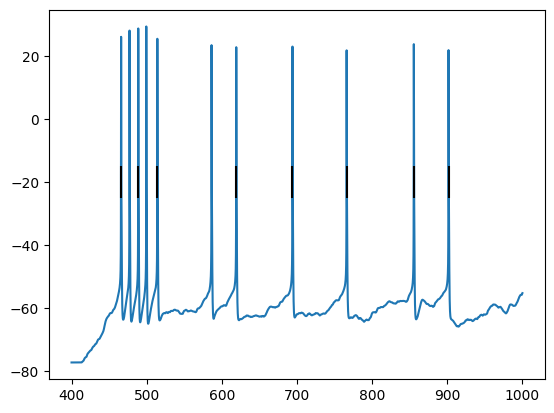

In [9]:
peak_threshold = 1

plt.plot(data_df.iloc[0].t, data_df.iloc[0].vm)
all_peaks = find_peaks(data_df.iloc[0].vm, threshold=peak_threshold)[0]
plt.vlines(data_df.iloc[0].t[all_peaks], -25, -15, color='k')

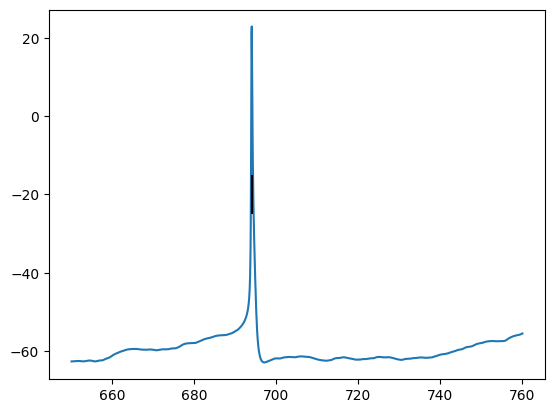

In [10]:
# plt.plot(data_df.iloc[0].t[:-1], data_df.iloc[0].ve)
plt.plot(spike_df.iloc[0].t, spike_df.iloc[0].vm)
all_peaks = find_peaks(spike_df.iloc[0].vm, threshold=peak_threshold)[0]
plt.vlines(spike_df.iloc[0].t[all_peaks], -25, -15, color='k')


Where is spike: 28
potential problems: []


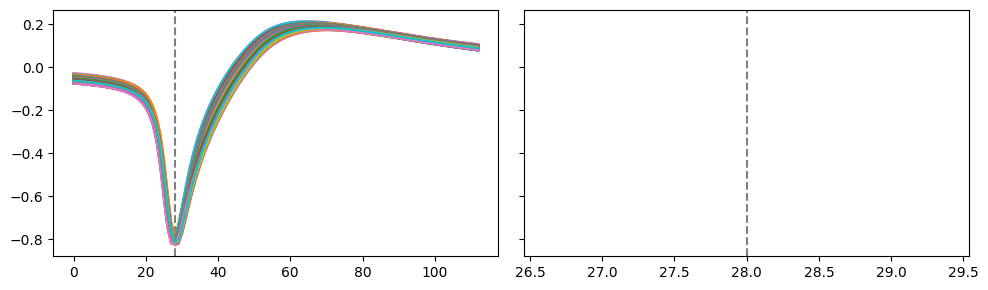

In [11]:
fig, axs = plt.subplots(1,2,figsize=(10,3),sharey=True)

offset_units = []
look_at_these = []

for probe in range(n_probes):

    probe_df = spike_df[spike_df['probe_num'] == probe]

    vm = probe_df.vm.iloc[0]
    t = probe_df.t.iloc[0]
    dt = t[1] - t[0]
    pre_spike_dur = 1.4
    duration = 5.6

    lb = pre_spike_dur
    ub = duration-pre_spike_dur

    all_peaks = find_peaks(vm, threshold=peak_threshold)[0]
    all_peak_times = t[all_peaks]
    for i, peak in enumerate(all_peak_times):
        if ((peak-lb) >= t[0]) and ((peak+ub) <= t[-1]):
            peak_time = peak
            peak_shift_i = all_peaks[i]
            break

    buff = 2
    start_time = peak_time - buff
    end_time = peak_time + 2*buff

    # approximate reduced timeseries condition
    t_cond = (t >= start_time) & (t < end_time)

    # find actual maximum channel
    temp_amps = []
    try:
        for _, row in probe_df.iterrows():
            wave = row.ve[t_cond]
            amp = np.max(wave) - np.min(wave)
            temp_amps.append(amp)
    except ValueError:
        raise Exception(f'ValueError: Length of Probe = {len(probe_df)} | Peak time = {peak_time}')
    
    # actual times for aligning waveform
    temp_amps = np.array(temp_amps)
    max_channel_i = np.argmax(temp_amps)

    max_channel_ve = probe_df[probe_df['channel_num']==max_channel_i].ve.iloc[0]

    # get new extracellular spike time
    peak_time_0 = peak_time
    
    min_peak = np.argmin(max_channel_ve[t_cond])
    min_peak_time = t[min_peak+peak_shift_i-int((buff/dt))]
    
    max_peak = np.argmax(max_channel_ve[t_cond])
    max_peak_time = t[max_peak+peak_shift_i-int((buff/dt))]
    
    min_diff = np.abs(peak_time_0-min_peak_time)
    max_diff = np.abs(peak_time_0-max_peak_time)

    # take whichever is more accurate
    if min_diff<max_diff:
        peak_time = min_peak_time
        peak = min_peak
        
    else:
        peak_time = max_peak_time
        peak = max_peak

    new_t_cond = (t >= peak_time - pre_spike_dur) & (t < peak_time - pre_spike_dur + duration)

    this_peak_idx = np.argwhere(t[new_t_cond] >= peak_time)[0][0]
    this_ve = max_channel_ve[new_t_cond]
    this_ve = this_ve/np.max(temp_amps)
    if this_ve[this_peak_idx]<0:
        axs[0].plot(this_ve)
    else:
        axs[1].plot(this_ve)
        
    if this_ve[20]<-0.25:       # TODO: What is this checking??
        look_at_these.append(probe)
        axs[1].plot(this_ve)
    
print('Where is spike:',this_peak_idx)
for i in range(2):
    axs[i].axvline(this_peak_idx,color='gray',linestyle='--',zorder=0)

# print('offset:',offset_units)
print('potential problems:',look_at_these)
plt.tight_layout();

[694.]


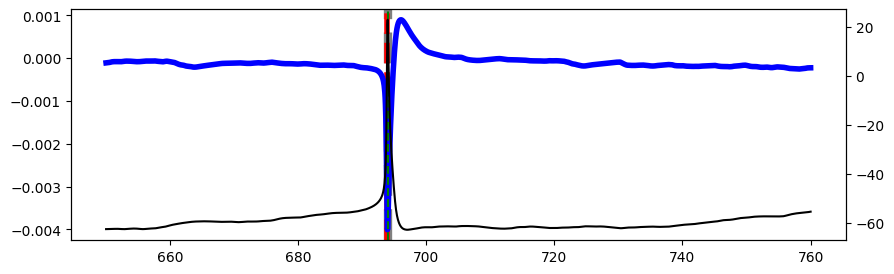

In [12]:
### Problem Units ###
unit = 98
test_df = spike_df[spike_df.probe_num == unit].copy()

t = test_df.t.iloc[0]
vm = test_df.vm.iloc[0]
ve = test_df.ve.iloc[0]

pre_spike_dur = 1.4
duration = 5.6

lb = pre_spike_dur
ub = duration - pre_spike_dur

all_peaks = find_peaks(vm, threshold=peak_threshold)[0]
all_peak_times = t[all_peaks]
print(all_peak_times)
for i, peak_time in enumerate(all_peak_times):
    if ((peak_time-lb)>=t[0]) and ((peak_time+ub)<=t[-1]):
        vm_spk = peak_time
        vm_spk_i = all_peaks[i]
        break

dt = t[1]-t[0]

# find the right spike time
buff = 2
t_cond = (t>=(vm_spk-buff))&(t<=(vm_spk+buff))

temp_amps = []
try:
    for _, row_df in test_df.iterrows():
        wave = row_df['ve']
        wave = wave[t_cond]

        amp = np.max(wave)-np.min(wave)

        temp_amps.append(amp)
except ValueError:
    raise Exception('ValueError: Length of Probe= %s | Peak time= %.2f'%(len(test_df),vm_spk))

temp_amps = np.array(temp_amps)
max_channel_i = np.argmax(temp_amps) # max channel without

max_chan_ve = test_df[test_df['channel_num']==max_channel_i]['ve'].iloc[0]

ve_spk = t[np.argmin(max_chan_ve[t_cond])+vm_spk_i-int((buff/dt))]

fig, ax = plt.subplots(1,1,figsize=(10,3))
ax.plot(t,max_chan_ve,color='b',linewidth=4)
ax.axvline(vm_spk,color='gray',linestyle='--',linewidth=6,zorder=0)
ax.axvline(ve_spk,color='r',linestyle='--',linewidth=4,zorder=0)

for peak in find_peaks(vm, threshold=peak_threshold)[0]:
    ax.axvline(t[peak],color='g',linestyle='--')

ax2 = ax.twinx()
ax2.plot(t,vm,color='k')



In [13]:
def find_n_closest_probes(probes, n_closest, max_channel_i = 25):
    
    num_probes, _, _ = np.shape(probes)
    distances = []
    
    for i in range(num_probes):
        probe = probes[i,:,:]
        x,y,z = probe[max_channel_i]
        dist = np.sqrt(x**2+y**2+z**2)
        distances.append(dist)
        
    print('Closest probe found at %s microns...'%np.min(distances))
    return np.argsort(distances)[:n_closest]  # np.argmin(distances)

def find_n_farthest_probes(probes, n_farthest, max_channel_i = 25):
    
    num_probes, _, _ = np.shape(probes)
    distances = []
    
    for i in range(num_probes):
        probe = probes[i,:,:]
        x,y,z = probe[max_channel_i]
        dist = np.sqrt(x**2+y**2+z**2)
        distances.append(dist)
        
    print('Farthest probe found at %s microns...'%np.max(distances))
    return np.argsort(distances)[-n_farthest:]  # np.argmax(distances)

## Closest Probe

In [14]:
closest_probe = find_n_closest_probes(probes, 1, max_channel_i=n_channels//2)
closest_probe_df = spike_df[spike_df.probe_num.isin(closest_probe)]
closest_probe_df.head()

Closest probe found at 11.176532159151513 microns...


,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num
4352,NMLCL000073,"[650.0499999999565, 650.0999999999565, 650.149...","[-62.672571244908205, -62.67047642840252, -62....","[0.00015984055235366, 0.00016001569079018632, ...",-6.458654,-315.00852,7.634513,1148,True,408.071733,68,0
4353,NMLCL000073,"[650.0499999999565, 650.0999999999565, 650.149...","[-62.672571244908205, -62.67047642840252, -62....","[0.00016222080297530184, 0.0001624113505237641...",-6.458654,-305.00852,7.634513,1148,True,408.071733,68,1
4354,NMLCL000073,"[650.0499999999565, 650.0999999999565, 650.149...","[-62.672571244908205, -62.67047642840252, -62....","[0.0001650253385963002, 0.0001652320966572228,...",-6.458654,-295.00852,7.634513,1148,True,408.071733,68,2
4355,NMLCL000073,"[650.0499999999565, 650.0999999999565, 650.149...","[-62.672571244908205, -62.67047642840252, -62....","[0.0001682450432427056, 0.00016846889728529613...",-6.458654,-285.00852,7.634513,1148,True,408.071733,68,3
4356,NMLCL000073,"[650.0499999999565, 650.0999999999565, 650.149...","[-62.672571244908205, -62.67047642840252, -62....","[0.00017185824827300534, 0.0001721001556381580...",-6.458654,-275.00852,7.634513,1148,True,408.071733,68,4


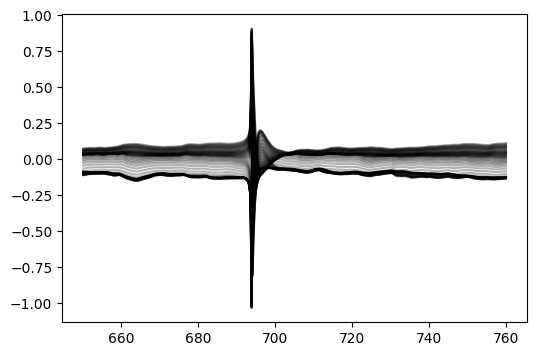

In [15]:
plt.figure(figsize=(6,4))
for _, row_df in closest_probe_df.iterrows():
    
    t = row_df['t']
    ve = row_df['ve']
    amp = np.max(ve)-np.min(ve)

    norm_ve = np.divide(ve,amp)
    
    plt.plot(t,norm_ve,'k',alpha=0.3)
    chan_num = row_df['channel_num']

# plt.xlim(1001.5,1030)

(680.0, 720.0)

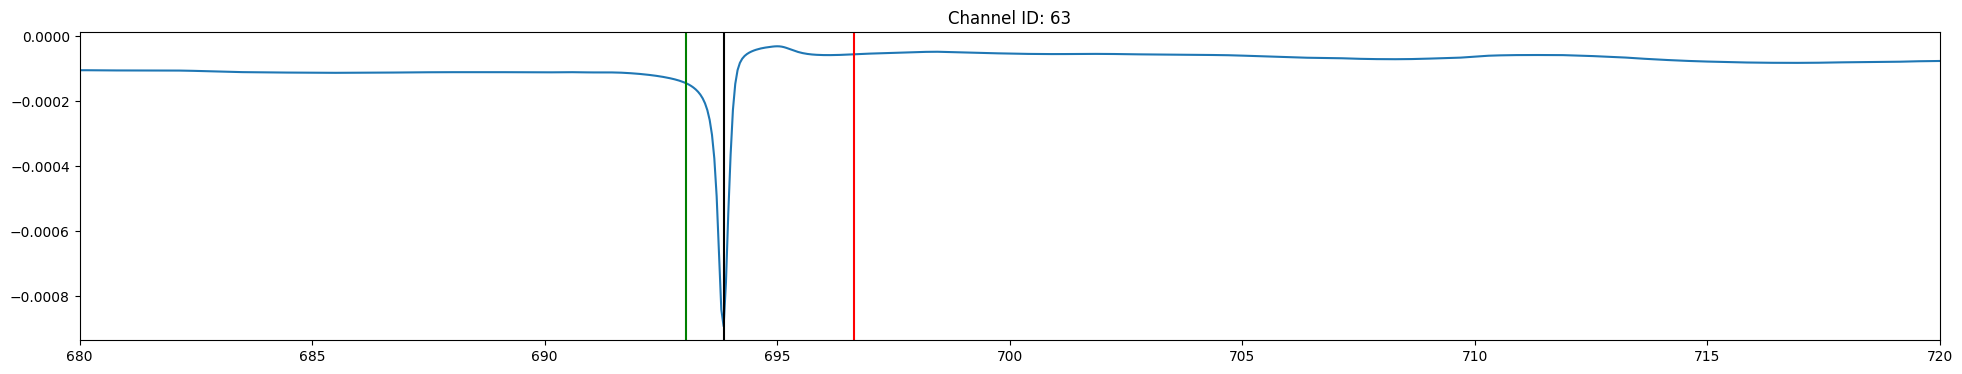

In [16]:
plt.figure(figsize=(24,4))
plt.plot(t,ve)

peak_time = t[np.argmin(ve)]

start_time = peak_time-0.8
end_time = start_time+3.6

plt.axvline(peak_time,color='k')
plt.axvline(start_time,color='g')
plt.axvline(end_time,color='r')

plt.title('Channel ID: %s'%chan_num)
plt.xlim(spike_start+30,spike_end-40)

## Farthest Probe

In [17]:
farthest_probe = find_n_farthest_probes(probes, 1, max_channel_i=n_channels//2)
farthest_probe_df = spike_df[spike_df.probe_num.isin(farthest_probe)]
farthest_probe_df.head()

Farthest probe found at 32.11033310655298 microns...


,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num
896,NMLCL000073,"[650.0499999999565, 650.0999999999565, 650.149...","[-62.672571244908205, -62.67047642840252, -62....","[0.00012485267501260094, 0.0001250171732752021...",-21.734218,-315.494051,-23.203312,1148,True,408.071733,14,0
897,NMLCL000073,"[650.0499999999565, 650.0999999999565, 650.149...","[-62.672571244908205, -62.67047642840252, -62....","[0.0001270133916788203, 0.00012718914099642384...",-21.734218,-305.494051,-23.203312,1148,True,408.071733,14,1
898,NMLCL000073,"[650.0499999999565, 650.0999999999565, 650.149...","[-62.672571244908205, -62.67047642840252, -62....","[0.0001291520105709198, 0.0001293396808940479,...",-21.734218,-295.494051,-23.203312,1148,True,408.071733,14,2
899,NMLCL000073,"[650.0499999999565, 650.0999999999565, 650.149...","[-62.672571244908205, -62.67047642840252, -62....","[0.00013128266121669943, 0.0001314829157353291...",-21.734218,-285.494051,-23.203312,1148,True,408.071733,14,3
900,NMLCL000073,"[650.0499999999565, 650.0999999999565, 650.149...","[-62.672571244908205, -62.67047642840252, -62....","[0.00013339771785449863, 0.0001336112210834763...",-21.734218,-275.494051,-23.203312,1148,True,408.071733,14,4


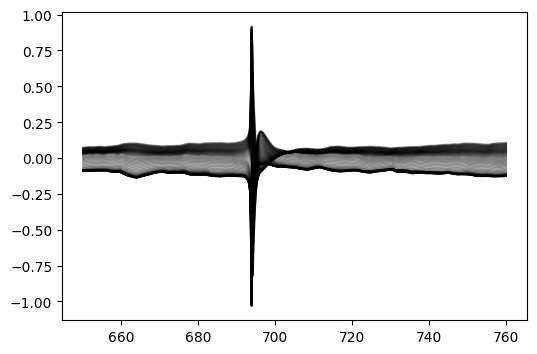

In [18]:
plt.figure(figsize=(6,4))
for _, row_df in farthest_probe_df.iterrows():
    
    t = row_df['t']
    ve = row_df['ve']
    amp = np.max(ve)-np.min(ve)

    norm_ve = np.divide(ve,amp)
    
    plt.plot(t,norm_ve,'k',alpha=0.3)
    chan_num = row_df['channel_num']

# plt.xlim(1001.5,1030)

(680.0, 720.0)

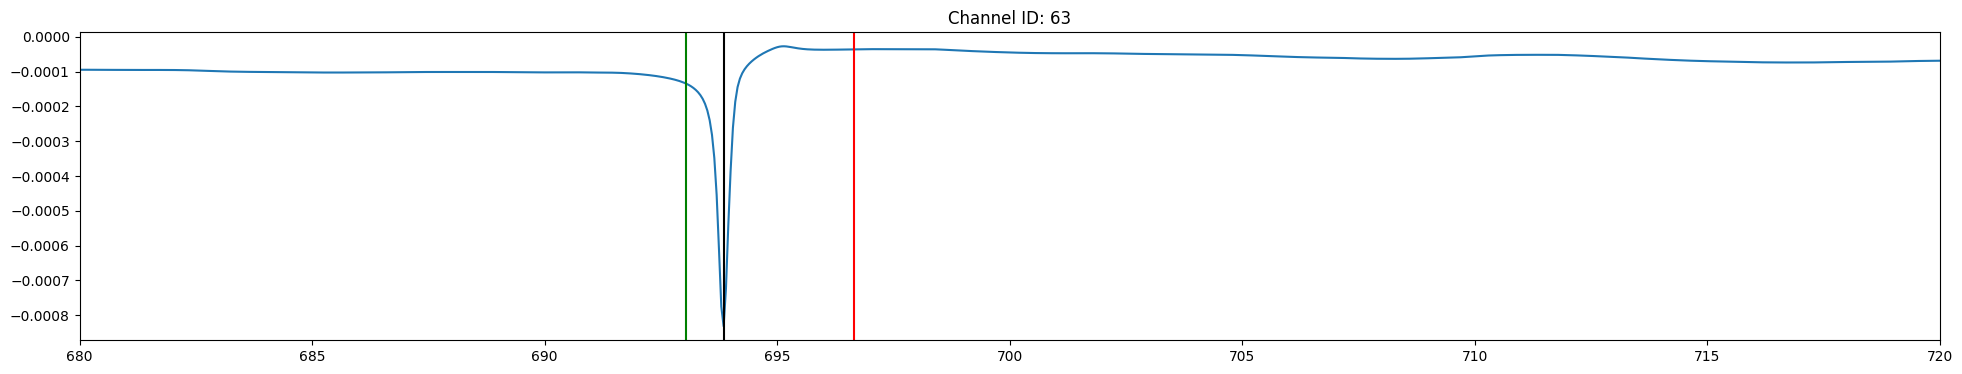

In [19]:
plt.figure(figsize=(24,4))
plt.plot(t,ve)

peak_time = t[np.argmin(ve)]

start_time = peak_time-0.8
end_time = start_time+3.6

plt.axvline(peak_time,color='k')
plt.axvline(start_time,color='g')
plt.axvline(end_time,color='r')

plt.title('Channel ID: %s'%chan_num)
plt.xlim(spike_start+30,spike_end-40)

## Maximum channel peak to align waveforms

identify center channel as channel corresponding to maximum amplitude
then select 15 channels above and 15 channels below

35
36
36


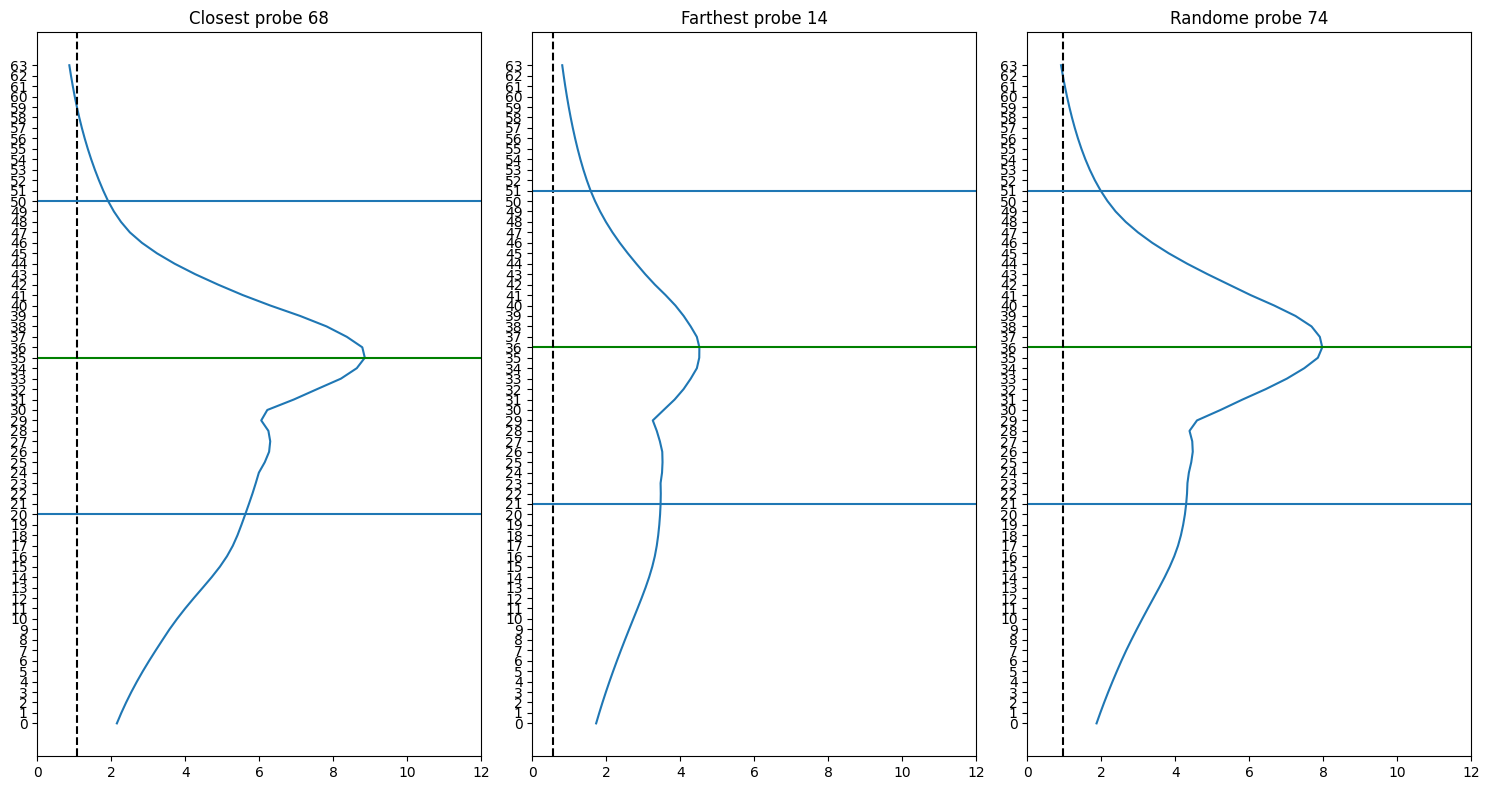

In [20]:
rand_probe = np.random.choice(num_probes)
rand_probe_df = spike_df[spike_df.probe_num == rand_probe]

amps_close = []
amps_far = []
amps_rand = []

for (_, row_close), (_, row_far), (_, row_rand) in zip(closest_probe_df.iterrows(), farthest_probe_df.iterrows(), rand_probe_df.iterrows()):

    amps_close.append(np.max(row_close.ve) - np.min(row_close.ve))
    amps_far.append(np.max(row_far.ve) - np.min(row_far.ve))
    amps_rand.append(np.max(row_rand.ve) - np.min(row_rand.ve))


fig, axs = plt.subplots(1, 3, figsize=(15,8))

for i in range(3):

    if i == 0:
        amps = amps_close
        title = f'Closest probe {closest_probe[0]}'
    elif i == 1:
        amps = amps_far
        title = f'Farthest probe {farthest_probe[0]}'
    else:
        amps = amps_rand
        title = f'Randome probe {rand_probe}'

    # axs[i].figure(figsize=(5,8))
    axs[i].plot(1e3*np.array(amps), np.arange(len(closest_probe_df)))
    axs[i].set_yticks(np.arange(len(closest_probe_df)))
    axs[i].set_xlim((0,12))

    true_max = np.argmax(amps)
    axs[i].axhline(true_max, color='g')

    axs[i].axvline(0.12*1e3*np.max(amps), color='k', linestyle='--')

    axs[i].axhline(true_max+15)
    axs[i].axhline(true_max-15)

    axs[i].set_title(title)

    print(true_max)

fig.tight_layout()

In [21]:
max_channel = 36  # based on farthest and random probes
max_channel_ve = spike_df[spike_df.channel_num == max_channel].ve.iloc[0]
low_channel_ve = spike_df[spike_df.channel_num == max_channel+15].ve.iloc[0]
t = spike_df[spike_df.channel_num == max_channel].t.iloc[0]

(692.3499999999166, 697.9499999999166)

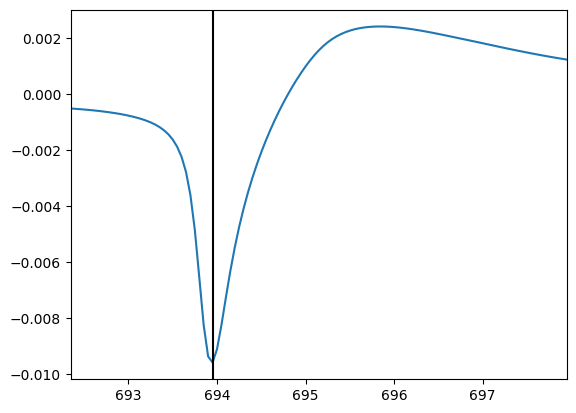

In [22]:
plt.plot(t, max_channel_ve)

peak_time = t[np.argmin(max_channel_ve)]

spike_duration = 5.6
start_time = peak_time - 1.6
end_time = start_time + spike_duration

plt.axvline(peak_time, color='k')
plt.xlim([start_time, end_time])
# ticks = [0.0,0.5,1.0,1.5,2.0,2.5]
# xticks = [start_time+i for i in ticks]
# plt.xticks(xticks,ticks);

## Signal Interpolation

In [23]:
conversion_factor = 1e3

In [24]:
spike_duration = 5.6
start_time = peak_time - 1.6
end_time = start_time + spike_duration

t_cond = (t >= start_time) & (t < end_time)
reduced_t = t[t_cond]
reduced_max_ve = conversion_factor * max_channel_ve[t_cond]
reduced_low_ve = conversion_factor * low_channel_ve[t_cond]

T = len(reduced_t)
T

113

In [25]:
start_time, end_time

(692.3499999999166, 697.9499999999166)

In [26]:
num_pts = 128
duration = reduced_t[-1] - reduced_t[0]
duration/num_pts

0.04374999999996021

In [27]:
interp_t = np.linspace(0, duration, T)
len(interp_t)

113

In [28]:
cs = CubicSpline(interp_t, reduced_max_ve, axis=0)
new_time = np.linspace(0,duration,num_pts)
new_max_ve = cs(new_time)

In [29]:
len(new_time), len(new_max_ve)

(128, 128)

In [30]:
cs = CubicSpline(interp_t,reduced_low_ve,axis=0)
new_time = np.linspace(0,duration,num_pts)
new_low_ve = cs(new_time)

In [31]:
len(new_time), len(new_low_ve)

(128, 128)

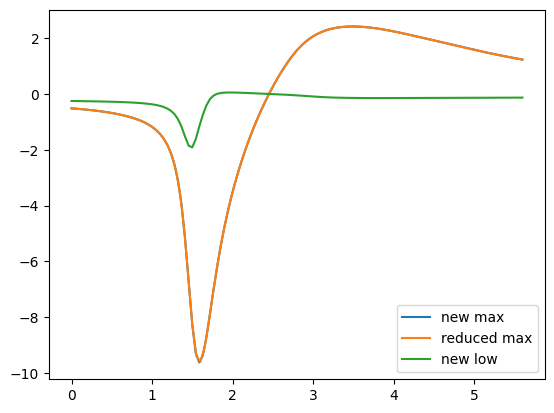

In [46]:
plt.plot(new_time,new_max_ve, label='new max')
plt.plot(interp_t,reduced_max_ve, label='reduced max')
plt.plot(new_time,new_low_ve, label='new low')
plt.legend(loc='lower right')

## Noise Inclusion

In [33]:
scaling_factor = 10
noise_generator = cn.powerlaw_psd_gaussian
p1 = 1
num_noisy_spikes = 500
p2 = (num_noisy_spikes, len(new_time))

args = [p1, p2]

noise_signals = scaling_factor * noise_generator(*args)
mean_noise = np.mean(noise_signals, axis=0)

In [34]:
np.shape(noise_signals), np.shape(mean_noise)

((500, 128), (128,))

2.1599214081691


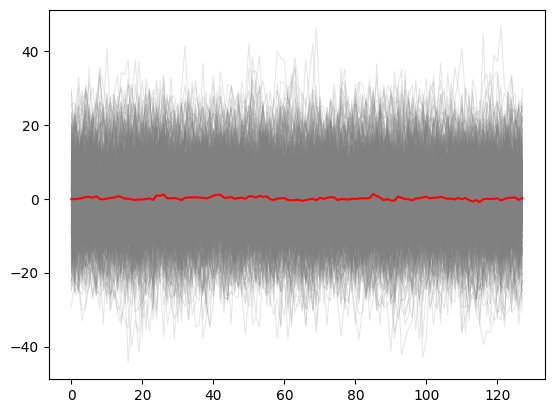

In [35]:
plt.figure()
plt.plot(np.transpose(noise_signals), color='gray', alpha=0.2, linewidth=0.75)

print(np.max(mean_noise) - np.min(mean_noise))
plt.plot(mean_noise, color='r')

39.43181636887748


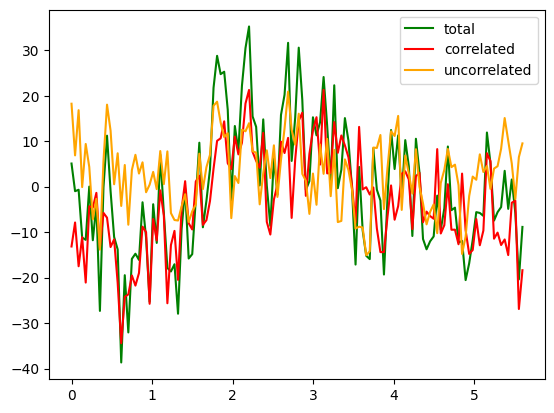

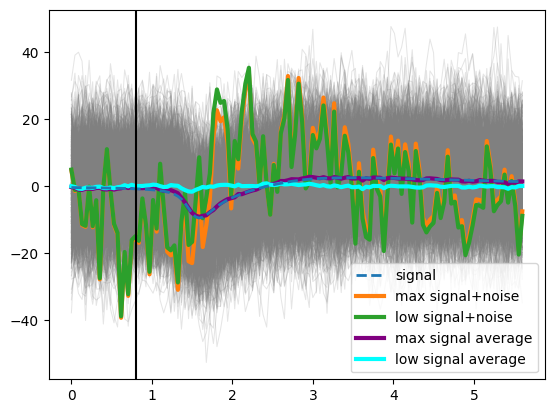

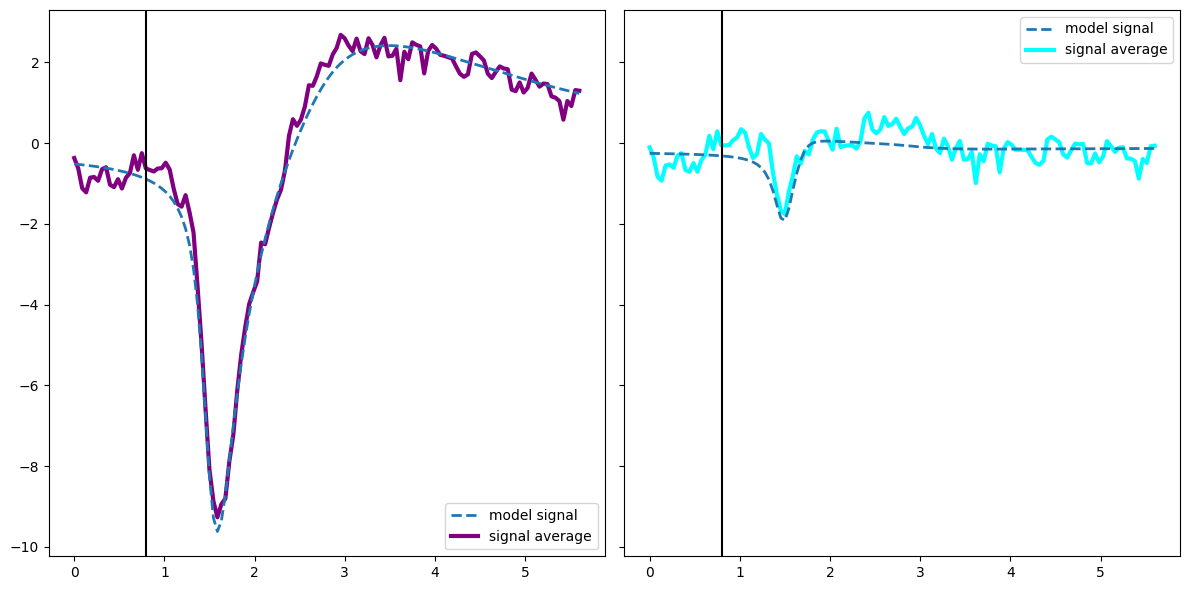

In [38]:
scaling_factor = 10 # 15, 25
noise_generator = cn.powerlaw_psd_gaussian
p1 = 1
p2 = len(new_time)
args = [p1,p2]

corr_noise_signal = scaling_factor*noise_generator(*args)
uncorr_noise_signal = scaling_factor*noise_generator(*args)
noise_signal = corr_noise_signal + uncorr_noise_signal

plt.figure()
plt.plot(new_time,noise_signal,'g',label='total')
plt.plot(new_time,corr_noise_signal,'r',label='correlated')
plt.plot(new_time,uncorr_noise_signal,'orange',label='uncorrelated')
plt.legend()

synth_max_ve = np.add(new_max_ve,noise_signal)
synth_low_ve = np.add(new_low_ve,noise_signal)

plt.figure()

# Spike-triggered average
# create 100 spikes recorded at the same distance and check average
synth_max_signals = []
synth_low_signals = []
noise_signals = []
for i in range(1000):

    noise_signal = scaling_factor*noise_generator(*args)

    noise_signals.append(noise_signal)
    
    max_signal = np.add(new_max_ve,noise_signal)
    synth_max_signals.append(list(max_signal))
    
    low_signal = np.add(new_low_ve,noise_signal)
    synth_low_signals.append(list(low_signal))
    
    plt.plot(new_time,max_signal,alpha=0.2,linewidth=0.75,color='gray',zorder=0)

mean_max_signal = np.mean(np.array(synth_max_signals),axis=0)
mean_low_signal = np.mean(np.array(synth_low_signals),axis=0)


plt.plot(new_time,new_max_ve,linestyle='--',linewidth=2,label='signal')
plt.plot(new_time,synth_max_ve,linewidth=3,label='max signal+noise',zorder=0)
plt.plot(new_time,synth_low_ve,linewidth=3,label='low signal+noise',zorder=0)

plt.plot(new_time,mean_max_signal,color='purple',linewidth=3,label='max signal average',zorder=0)
plt.plot(new_time,mean_low_signal,color='cyan',linewidth=3,label='low signal average',zorder=0)

print(np.max(noise_signal)-np.min(noise_signal))

plt.axvline(0.8,color='k')
plt.legend()


# amplitude normalized to see noise
fig, axs = plt.subplots(1,2,sharey=True,figsize=(12,6))
axs[0].plot(new_time,new_max_ve,linestyle='--',linewidth=2,label='model signal')
axs[0].plot(new_time,mean_max_signal,color='purple',linewidth=3,label='signal average',zorder=0)
axs[0].legend()

axs[1].plot(new_time,new_low_ve,linestyle='--',linewidth=2,label='model signal')
axs[1].plot(new_time,mean_low_signal,color='cyan',linewidth=3,label='signal average',zorder=0)
axs[1].legend()

for i in range(2):
    axs[i].axvline(0.8,color='k')

plt.tight_layout();




128 128


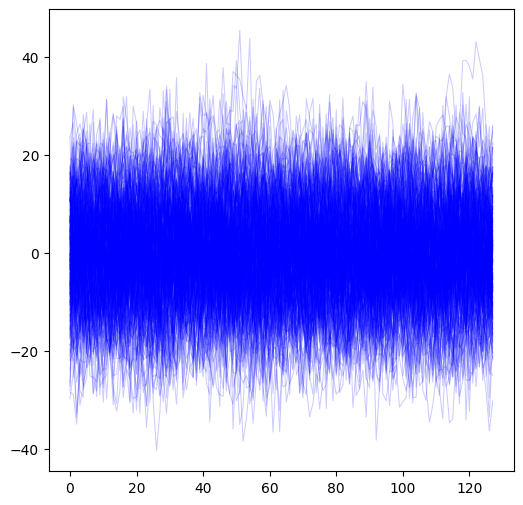

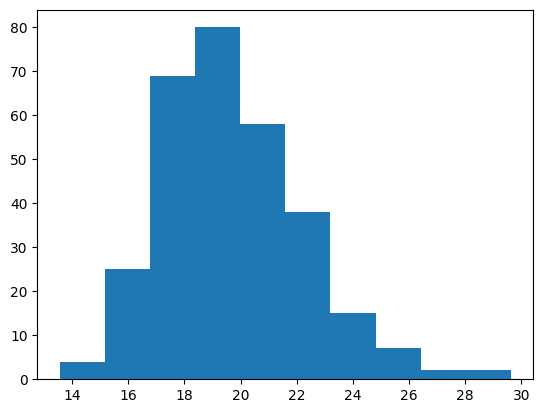

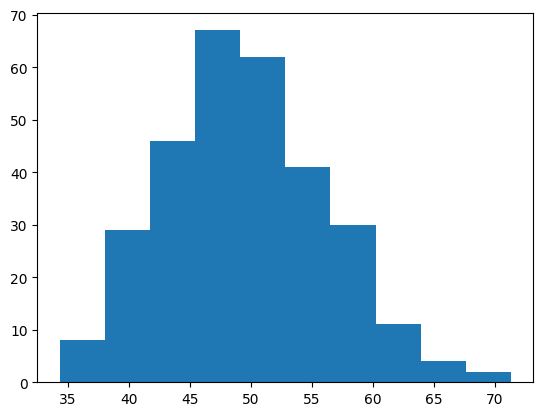

In [42]:
# note noise level depends on electrode size - target noise amplitude 50-100 
scaling_factor = 10  # 15, 25
noise_generator = cn.powerlaw_psd_gaussian
p1 = 1
p2 = 128
args = [p1,p2]

plt.figure(figsize=(6,6))
noise_stdevs = []
noise_depths = []
print(p2,num_pts)
for i in range(300):
    noise_signal = scaling_factor*noise_generator(*args)
    
    
    plt.plot(noise_signal,color='b',alpha=0.2,linewidth=0.75)
    
    noise_stdevs.append(np.std(noise_signal))
    noise_depths.append(np.max(noise_signal)-np.min(noise_signal))


plt.figure()
noise_amplitudes = 2*np.array(noise_stdevs) # 1x = 68%, 2x = 95%
plt.hist(noise_amplitudes);

plt.figure()
noise_abs_amplitudes = np.array(noise_depths) # 1x = 68%, 2x = 95%
plt.hist(noise_abs_amplitudes);

## Preprocessing

In [88]:
def preprocess_probe_data(probe_df,max_channel_i=15,downsample=82,resample=128,conversion_factor=1e3, scaling_factor=10,num_noisy_spikes=100):
    
    preprocessed_probe_df = probe_df.copy()
    new_ves = []
    all_amps = []
    
    duration = 5.6
    peak_shift = 1.4 # duration/4
    

    
    t= probe_df.t.iloc[0]
    dt = t[1]-t[0]
    Fs = 1000./dt
    
    # approximate times for aligning waveforms    
    max_chan_ve = probe_df[probe_df['channel_num']==max_channel_i]['ve'].iloc[0]
    peak_time = t[np.argmin(max_chan_ve)]
    
    start_time = peak_time-peak_shift
    end_time = start_time+duration
    
    # approximate reduced timeseries condition
    t_cond = (t>=start_time)&(t<end_time)
    
    # find actual maximum channel
    temp_amps = []
    for _, row_df in probe_df.iterrows():
        wave = row_df['ve']
        wave = wave[t_cond]
        amp = np.max(wave)-np.min(wave)
        
        temp_amps.append(amp)
        
    # actual times for aligning waveforms
    temp_amps = np.array(temp_amps)
    max_channel_i = np.argmax(temp_amps)
    print(max_channel_i)
    
    max_chan_ve = probe_df[probe_df['channel_num']==max_channel_i]['ve'].iloc[0]
    peak_time = t[np.argmin(max_chan_ve)]
    
    # readjust after finding real max
    start_time = peak_time-peak_shift
    end_time = start_time+duration

    
    # reduced timeseries
    t_cond = (t>=start_time)&(t<end_time)
    reduced_t = t[t_cond]
    

    T = len(reduced_t)
    
    # interpolation grid
    interp_t = np.linspace(0,duration,T)
    
    
    
    # downsample and upsample grids
    down_t = np.linspace(0,duration,downsample)
    if resample is False:
        re_t = down_t
    else:
        re_t = np.linspace(0,duration,resample)
    
    
    # iterate over channels
    for _, row_df in probe_df.iterrows():
        
        # extract signal 
        ve = row_df['ve']
        reduced_ve = ve[t_cond]
        
        # scale signal
        reduced_ve = conversion_factor*reduced_ve 
        
        # downsample signal
        cs = CubicSpline(interp_t,reduced_ve,axis=0)
        new_ve = cs(down_t)
        
        # noise details
        noise_scale = 10 # 15, 25
        noise_generator = cn.powerlaw_psd_gaussian
        p1 = 1
        p2 = (num_noisy_spikes,len(new_ve))
        args = [p1,p2]

        
        
        # add "single-trial" noise
        noise_signals = scaling_factor*noise_generator(*args)
        uncorr_noise_signal = np.mean(noise_signals,axis=0)

        synth_ve = np.add(new_ve,uncorr_noise_signal)
        
        
        
        # resample signal
        if resample is False:
            new_ve = synth_ve
        else:
            cs = CubicSpline(down_t,synth_ve,axis=0)
            new_ve = cs(re_t)
            
        # center channel
        median_ve = np.median(new_ve,axis=0)
        new_ve = np.subtract(new_ve,median_ve) 
            
        amp = np.max(new_ve)-np.min(new_ve)
        
        
        new_ves.append(new_ve)
        all_amps.append(amp)
    
    preprocessed_probe_df['ve'] = new_ves
    preprocessed_probe_df['t'] = [re_t for _ in range(len(new_ves))]
    preprocessed_probe_df['amplitude'] = all_amps
    
    return preprocessed_probe_df
        

In [89]:
prep_closest_df =  preprocess_probe_data(closest_probe_df, max_channel_i=max_channel, resample=128, conversion_factor=1e3, num_noisy_spikes=500)
prep_closest_df.head()

35


,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num,amplitude
4352,NMLCL000073,"[0.0, 0.04409448818897638, 0.08818897637795275...","[-62.672571244908205, -62.67047642840252, -62....","[0.2875726576555491, 0.7301334234618666, 0.714...",-6.458654,-315.00852,7.634513,1148,True,408.071733,68,0,3.521765
4353,NMLCL000073,"[0.0, 0.04409448818897638, 0.08818897637795275...","[-62.672571244908205, -62.67047642840252, -62....","[-0.2384203905166406, 0.1603031741950437, 0.12...",-6.458654,-305.00852,7.634513,1148,True,408.071733,68,1,3.498632
4354,NMLCL000073,"[0.0, 0.04409448818897638, 0.08818897637795275...","[-62.672571244908205, -62.67047642840252, -62....","[0.371214414186522, 0.41460445979662375, 0.505...",-6.458654,-295.00852,7.634513,1148,True,408.071733,68,2,2.740743
4355,NMLCL000073,"[0.0, 0.04409448818897638, 0.08818897637795275...","[-62.672571244908205, -62.67047642840252, -62....","[-0.7422088419490432, -0.9811531512476551, -0....",-6.458654,-285.00852,7.634513,1148,True,408.071733,68,3,3.692672
4356,NMLCL000073,"[0.0, 0.04409448818897638, 0.08818897637795275...","[-62.672571244908205, -62.67047642840252, -62....","[0.7031272467495273, 0.7396430175834705, 0.707...",-6.458654,-275.00852,7.634513,1148,True,408.071733,68,4,2.869330


0.18250766354427303


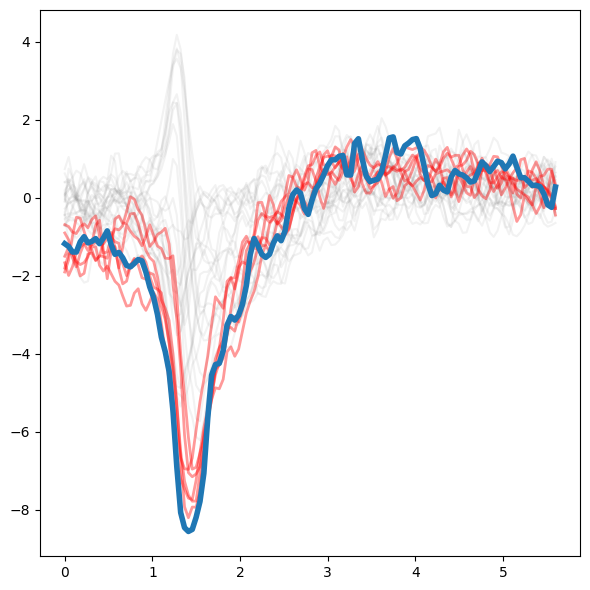

In [90]:
fig = plt.figure(figsize=(6,6))

all_amps = prep_closest_df.amplitude.values
max_amp = np.max(all_amps)
max_threshold = 0.12

medians = []
    
for _, row_df in prep_closest_df.iterrows():
    
    wave = row_df['ve']
    time = row_df['t']
    amp = np.max(wave)-np.min(wave)
    
    medians.append(np.median(wave))
    
    chan = row_df['channel_num']
    if chan==max_channel:
        c = 'tab:blue'
        z = np.inf
        width = 4
        alpha = 1
        
        peak_to_trough_ratio = -1*np.max(wave)/np.min(wave)
    else:
        c = 'r'
        z = 1
        width = 2
        alpha = 0.4
        
#     norm_wave = np.divide(wave,amp)
    norm_wave = wave
    
    
    if (chan >= max_channel-15 )& (chan <= max_channel+15):
    
        if amp>=8:  # max_threshold*max_amp:
            plt.plot(time,norm_wave,color=c,zorder=z,linewidth=width,alpha=alpha)

        else:
            plt.plot(time,norm_wave,zorder=0,alpha=0.1,color='gray')
        
#     plt.xlim([0,2.7])
#     plt.xlabel('Time (ms)',size='x-large')
#     plt.ylabel('Ve (normalized)',size='x-large')

plt.tight_layout()
print(peak_to_trough_ratio)   
# figname = 'example_sc_model.pdf'
# fig.savefig(figname,format='pdf')

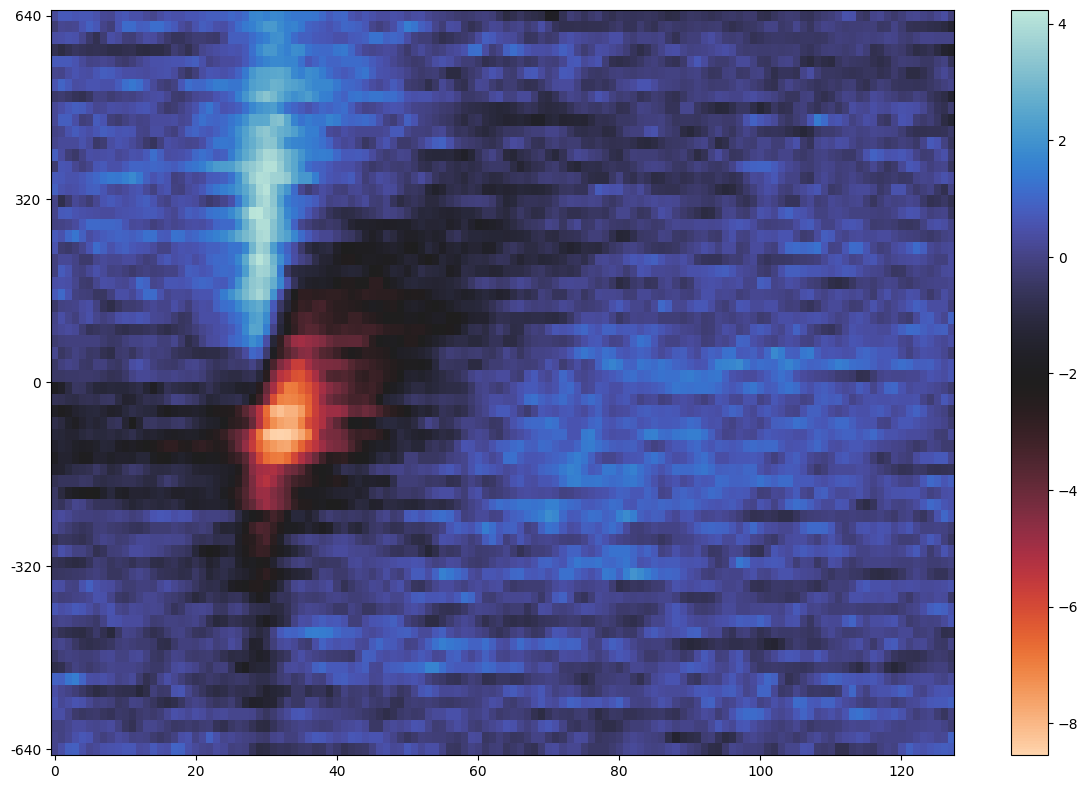

In [92]:
waves=[]
for _,row_df in prep_closest_df.iterrows():
    wave = list(row_df['ve'])
    
    waves.append(wave)
    

waves = np.array(waves)

icefire_cmap = sns.color_palette("icefire_r", as_cmap=True)

fig, axs = plt.subplots(1,1, figsize=(12,8))
im = axs.imshow(waves, interpolation='nearest', aspect='auto', cmap=icefire_cmap, zorder=1)
# axs.plot((-center_wave*64) + (n_channels-1)/2, color='white',zorder=12)
# axs.plot((-center_wave*60)+4, color='white',zorder=12)

# axs.set_xticks([1000*i for i in range(0,7)])
# axs.set_xticklabels([100*i for i in range(4,11)])
# axs.set_xlim([2000, 2080])
# axs.set_yticks([0, 15, 31, 47, 63])
axs.set_yticks([(n_channels-1)*i for i in [0, 0.25, 0.5, 0.75, 1]])
axs.set_yticklabels([int(n_channels*i*10) for i in [1, 0.5, 0, -0.5, -1]])
# axs.set_yticklabels([320, 160, 0, -160, -320])
fig.colorbar(im)
fig.tight_layout()
# fig.savefig(os.path.join(sim_dir, sim_label, 'closest_probes.png'), dpi=300)

In [93]:
prep_farthest_df =  preprocess_probe_data(farthest_probe_df, max_channel_i=max_channel, resample=128, conversion_factor=1e3, num_noisy_spikes=500)
prep_farthest_df.head()

36


,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num,amplitude
896,NMLCL000073,"[0.0, 0.04409448818897638, 0.08818897637795275...","[-62.672571244908205, -62.67047642840252, -62....","[1.3382599805941156, 1.1305062531459622, 1.080...",-21.734218,-315.494051,-23.203312,1148,True,408.071733,14,0,2.531794
897,NMLCL000073,"[0.0, 0.04409448818897638, 0.08818897637795275...","[-62.672571244908205, -62.67047642840252, -62....","[0.8490376041011676, 0.7027407400113141, 0.572...",-21.734218,-305.494051,-23.203312,1148,True,408.071733,14,1,3.495403
898,NMLCL000073,"[0.0, 0.04409448818897638, 0.08818897637795275...","[-62.672571244908205, -62.67047642840252, -62....","[-0.3298683464834981, -0.9186478227974552, -0....",-21.734218,-295.494051,-23.203312,1148,True,408.071733,14,2,3.806808
899,NMLCL000073,"[0.0, 0.04409448818897638, 0.08818897637795275...","[-62.672571244908205, -62.67047642840252, -62....","[0.4416582072093972, 0.22438907657756682, 0.03...",-21.734218,-285.494051,-23.203312,1148,True,408.071733,14,3,3.428453
900,NMLCL000073,"[0.0, 0.04409448818897638, 0.08818897637795275...","[-62.672571244908205, -62.67047642840252, -62....","[0.5362970532583624, 0.5052624318003389, 0.144...",-21.734218,-275.494051,-23.203312,1148,True,408.071733,14,4,3.120094


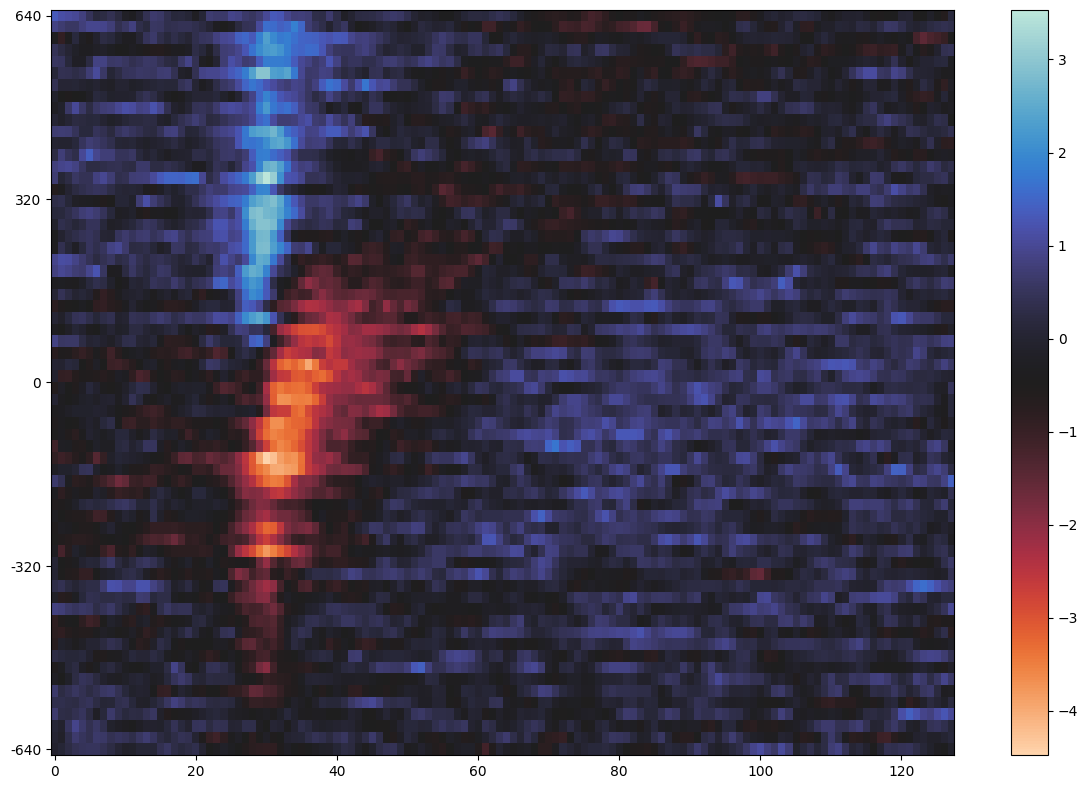

In [94]:
waves=[]
for _,row_df in prep_farthest_df.iterrows():
    wave = list(row_df['ve'])
    
    waves.append(wave)
    

waves = np.array(waves)

icefire_cmap = sns.color_palette("icefire_r", as_cmap=True)

fig, axs = plt.subplots(1,1, figsize=(12,8))
im = axs.imshow(waves, interpolation='nearest', aspect='auto', cmap=icefire_cmap, zorder=1)
# axs.plot((-center_wave*64) + (n_channels-1)/2, color='white',zorder=12)
# axs.plot((-center_wave*60)+4, color='white',zorder=12)

# axs.set_xticks([1000*i for i in range(0,7)])
# axs.set_xticklabels([100*i for i in range(4,11)])
# axs.set_xlim([2000, 2080])
# axs.set_yticks([0, 15, 31, 47, 63])
axs.set_yticks([(n_channels-1)*i for i in [0, 0.25, 0.5, 0.75, 1]])
axs.set_yticklabels([int(n_channels*i*10) for i in [1, 0.5, 0, -0.5, -1]])
# axs.set_yticklabels([320, 160, 0, -160, -320])
fig.colorbar(im)
fig.tight_layout()
# fig.savefig(os.path.join(sim_dir, sim_label, 'closest_probes.png'), dpi=300)

## Closest Probes ###

In [ ]:
closest_probes = find_n_closest_probes(probes, n_probes//2, max_channel_i=n_channels//2)
closest_probes_df = data_df[data_df.probe_num.isin(closest_probes)]
closest_probes_df.head()

In [11]:
avg_waves_close = []

for channel_num in range(num_channels):

    channel_df = closest_probes_df[closest_probes_df.channel_num == channel_num]

    waves = []

    for _, row in channel_df.iterrows():

        ve = row.ve
        amp = np.max(ve) - np.min(ve)
        norm_ve = np.divide(ve, amp)
        wave = list(norm_ve)
        waves.append(wave)

    waves = np.array(waves)
    channel_avg = np.average(waves, 0)

    avg_waves_close.append(channel_avg)

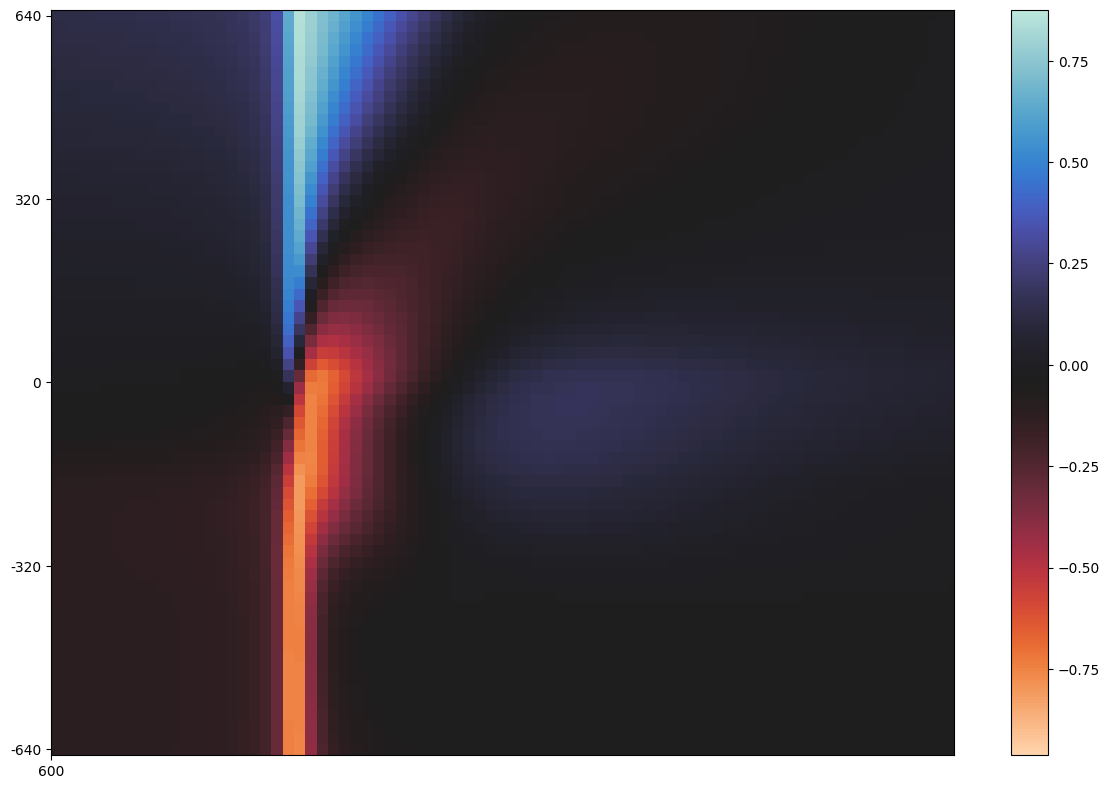

In [12]:
icefire_cmap = sns.color_palette("icefire_r", as_cmap=True)

fig, axs = plt.subplots(1,1, figsize=(12,8))
im = axs.imshow(avg_waves_close, interpolation='nearest', aspect='auto', cmap=icefire_cmap, zorder=1)
# axs.plot((-center_wave*64) + (n_channels-1)/2, color='white',zorder=12)
# axs.plot((-center_wave*60)+4, color='white',zorder=12)

axs.set_xticks([1000*i for i in range(0,7)])
axs.set_xticklabels([100*i for i in range(4,11)])
axs.set_xlim([2000, 2080])
# axs.set_yticks([0, 15, 31, 47, 63])
axs.set_yticks([(n_channels-1)*i for i in [0, 0.25, 0.5, 0.75, 1]])
axs.set_yticklabels([int(n_channels*i*10) for i in [1, 0.5, 0, -0.5, -1]])
# axs.set_yticklabels([320, 160, 0, -160, -320])
fig.colorbar(im)
fig.tight_layout()
# fig.savefig(os.path.join(sim_dir, sim_label, 'closest_probes.png'), dpi=300)

## Farthest Probes

In [13]:
farthest_probes = find_n_farthest_probes(probes, n_probes//2, max_channel_i=n_channels//2)
farthest_probes_df = data_df[data_df.probe_num.isin(farthest_probes)]
farthest_probes_df.head()

Farthest probe found at 32.11033310655298 microns...


,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num
128,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.3655621947126281e-05, 1.365550295982663e-05...",19.739821,-323.302918,14.702257,1147,True,408.071733,2,0
129,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.5973996276141474e-05, 1.597387642205759e-05...",19.739821,-313.302918,14.702257,1147,True,408.071733,2,1
130,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.837185264591956e-05, 1.8371732444274937e-05...",19.739821,-303.302918,14.702257,1147,True,408.071733,2,2
131,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.0825257878216612e-05, 2.0825137639752336e-0...",19.739821,-293.302918,14.702257,1147,True,408.071733,2,3
132,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.33211097541704e-05, 2.332098968637278e-05, ...",19.739821,-283.302918,14.702257,1147,True,408.071733,2,4


In [14]:
farthest_probe = find_n_farthest_probes(probes, 1, max_channel_i=n_channels//2)
farthest_probe_df = data_df[data_df.probe_num.isin(farthest_probe)]
farthest_probe_df.head()

Farthest probe found at 32.11033310655298 microns...


,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num
896,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.3254017898681725e-05, 1.3253938743597239e-0...",-21.734218,-315.494051,-23.203312,1147,True,408.071733,14,0
897,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.5128915093851535e-05, 1.5128836801857231e-0...",-21.734218,-305.494051,-23.203312,1147,True,408.071733,14,1
898,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.7022558997414367e-05, 1.7022481722131495e-0...",-21.734218,-295.494051,-23.203312,1147,True,408.071733,14,2
899,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.8931652390301817e-05, 1.893157627939399e-05...",-21.734218,-285.494051,-23.203312,1147,True,408.071733,14,3
900,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.0855571282084985e-05, 2.0855496504396556e-0...",-21.734218,-275.494051,-23.203312,1147,True,408.071733,14,4


In [15]:
np.unique(farthest_probes_df.probe_num)

array([ 2,  3,  5,  6,  7,  9, 11, 14, 16, 18, 21, 22, 23, 24, 27, 28, 30,
       41, 43, 44, 45, 46, 48, 50, 52, 53, 56, 57, 58, 60, 61, 64, 66, 67,
       72, 73, 74, 77, 79, 81, 82, 83, 84, 86, 88, 90, 91, 95, 96, 98])

In [16]:
avg_waves_far = []

for channel_num in range(num_channels):

    channel_df = farthest_probes_df[farthest_probes_df.channel_num == channel_num]

    waves = []

    for _, row in channel_df.iterrows():

        ve = row.ve
        amp = np.max(ve) - np.min(ve)
        norm_ve = np.divide(ve, amp)
        wave = list(norm_ve)
        waves.append(wave)

    waves = np.array(waves)
    channel_avg = np.average(waves, 0)

    avg_waves_far.append(channel_avg)

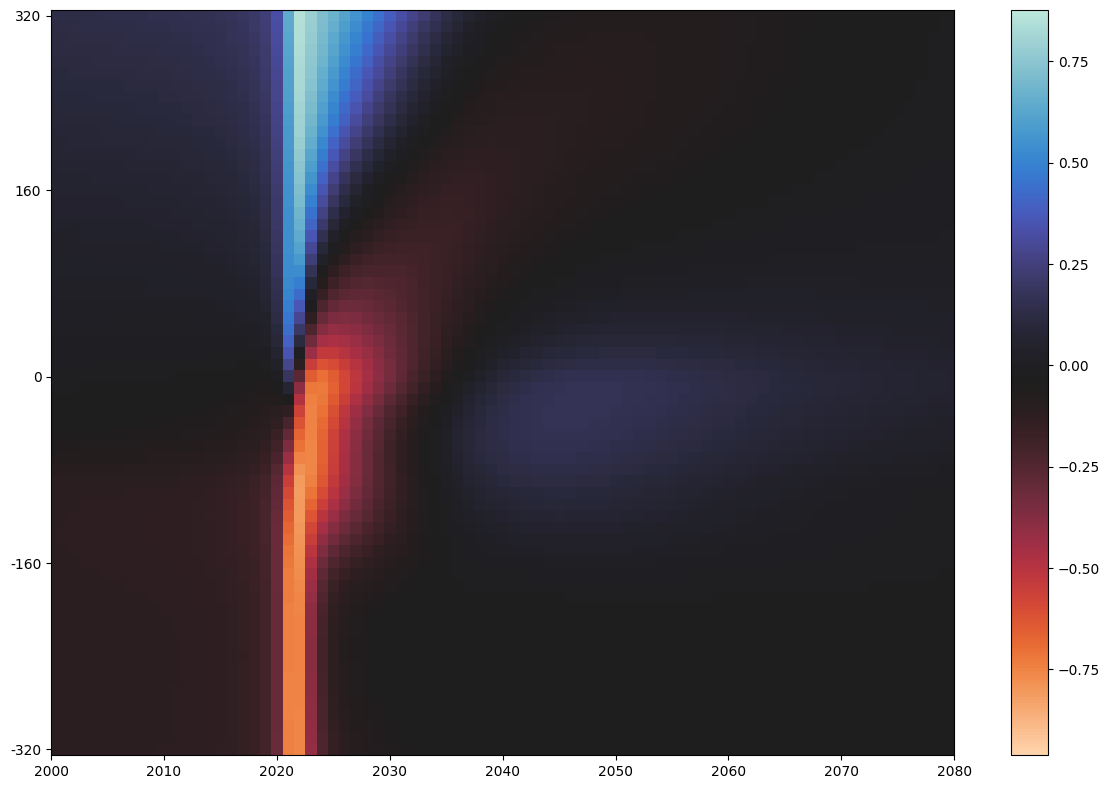

In [17]:
icefire_cmap = sns.color_palette("icefire_r", as_cmap=True)

fig, axs = plt.subplots(1,1, figsize=(12,8))
im = axs.imshow(avg_waves_far, interpolation='nearest', aspect='auto', cmap=icefire_cmap)
axs.set_xlim([2000, 2080])
axs.set_yticks([0, 15, 31, 47, 63])
axs.set_yticklabels([320, 160, 0, -160, -320])
fig.colorbar(im)
fig.tight_layout()
# fig.savefig(os.path.join(sim_dir, sim_label, 'farthest_probes.png'), dpi=300)

### Compare farthest vs closest data

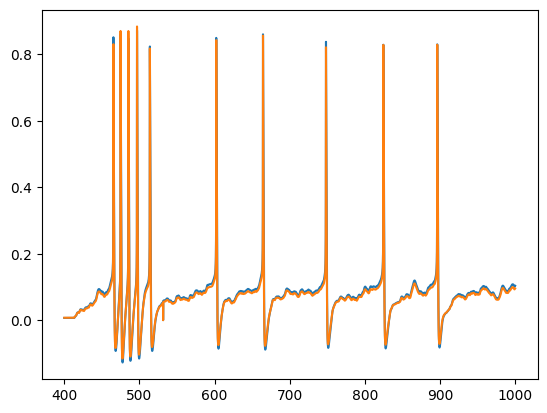

In [18]:
reduced_t = closest_probes_df.iloc[0].t[0:6000]

center_closest_ve = closest_probe_df.iloc[0].ve
norm_center_closest_ve = np.divide(center_closest_ve, np.max(center_closest_ve)-np.min(center_closest_ve))

center_farthest_ve = farthest_probe_df.iloc[0].ve
norm_center_farthest_ve = np.divide(center_farthest_ve, np.max(center_farthest_ve)-np.min(center_farthest_ve))

plt.plot(reduced_t, norm_center_closest_ve)
plt.plot(reduced_t, norm_center_farthest_ve)

In [21]:
reduced_t[2080]

608.0000000000697

### Closest

In [23]:
closest_probe_df.head()

,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num
4352,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.4557046339788114e-05, 1.455693599429246e-05...",-6.458654,-315.00852,7.634513,1147,True,408.071733,68,0
4353,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.6983757756701326e-05, 1.6983648745429887e-0...",-6.458654,-305.00852,7.634513,1147,True,408.071733,68,1
4354,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.936773590150133e-05, 1.9367627865172176e-05...",-6.458654,-295.00852,7.634513,1147,True,408.071733,68,2
4355,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.1732533931281357e-05, 2.1732426570531476e-0...",-6.458654,-285.00852,7.634513,1147,True,408.071733,68,3
4356,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.4094755009214806e-05, 2.4094648088360264e-0...",-6.458654,-275.00852,7.634513,1147,True,408.071733,68,4


In [24]:
prep_closest_probe_df, max_close_channel = preprocess_probe_data(closest_probe_df, resample=128, scaling_factor=20, conversion_factor=1e3, num_noisy_spikes=500)
max_close_channel

35

0.39997924130592705


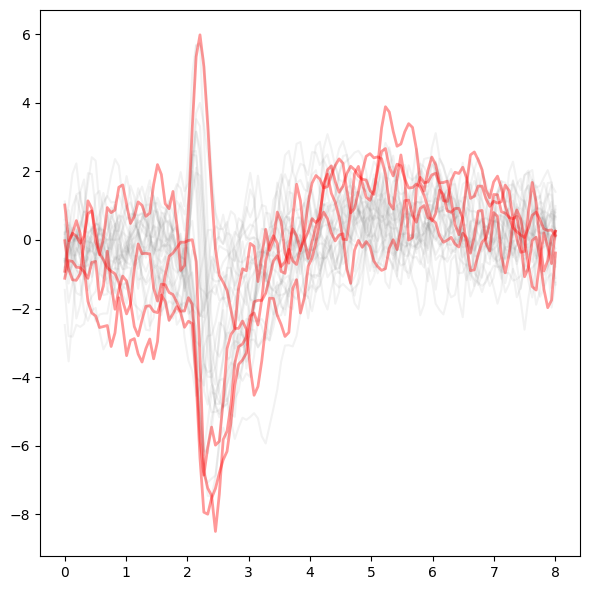

In [25]:
fig = plt.figure(figsize=(6,6))

all_amps = prep_closest_probe_df.amplitude.values
max_amp = np.max(all_amps)
max_threshold = 0.12

medians = []
    
for _, row_df in prep_closest_probe_df.iterrows():
    
    wave = row_df['ve']
    time = row_df['t']
    amp = np.max(wave)-np.min(wave)
    
    medians.append(np.median(wave))
    
    chan = row_df['channel_num']
    if chan==max_close_channel:
        c = 'C0'
        z = np.inf
        width = 4
        alpha = 1
        
        peak_to_trough_ratio = -1*np.max(wave)/np.min(wave)
    else:
        c = 'r'
        z = 1
        width = 2
        alpha = 0.4
        
#     norm_wave = np.divide(wave,amp)
    norm_wave = wave
    
    
    if (chan>=max_close_channel-15)&(chan<=max_close_channel+15):
    
        if amp>=10:#max_threshold*max_amp
            plt.plot(time,norm_wave,color=c,zorder=z,linewidth=width,alpha=alpha)

        else:
            plt.plot(time,norm_wave,zorder=0,alpha=0.1,color='gray')
        
#     plt.xlim([0,2.7])
#     plt.xlabel('Time (ms)',size='x-large')
#     plt.ylabel('Ve (normalized)',size='x-large')

plt.tight_layout()
print(peak_to_trough_ratio)   
# figname = 'example_sc_model.pdf'
# fig.savefig(figname,format='pdf')

In [31]:
prep_closest_probe_df.head()

,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num,amplitude
4352,NMLCL000073,"[0.0, 0.02125984251968504, 0.04251968503937008...","[-77.18251311792972, -77.18252912640395, -77.1...","[-0.028927574853232163, -0.08755002209168428, ...",-6.458654,-315.00852,7.634513,1147,True,408.071733,68,0,5.745217
4353,NMLCL000073,"[0.0, 0.02125984251968504, 0.04251968503937008...","[-77.18251311792972, -77.18252912640395, -77.1...","[-0.13521116870095454, 0.3045212366169354, 0.5...",-6.458654,-305.00852,7.634513,1147,True,408.071733,68,1,3.800374
4354,NMLCL000073,"[0.0, 0.02125984251968504, 0.04251968503937008...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.4160613861303475, 0.7775296691814995, 1.031...",-6.458654,-295.00852,7.634513,1147,True,408.071733,68,2,4.185318
4355,NMLCL000073,"[0.0, 0.02125984251968504, 0.04251968503937008...","[-77.18251311792972, -77.18252912640395, -77.1...","[-0.26512040238407053, -0.5458697115684562, 0....",-6.458654,-285.00852,7.634513,1147,True,408.071733,68,3,3.699417
4356,NMLCL000073,"[0.0, 0.02125984251968504, 0.04251968503937008...","[-77.18251311792972, -77.18252912640395, -77.1...","[0.580778896892263, 0.8165907286637902, -0.194...",-6.458654,-275.00852,7.634513,1147,True,408.071733,68,4,3.786974


In [33]:
pre_waves_close = []

for _, row_df in prep_closest_probe_df.iterrows():

    wave = list(row_df['ve'])
    pre_waves_close.append(wave)

pre_waves_close = np.array(pre_waves_close)


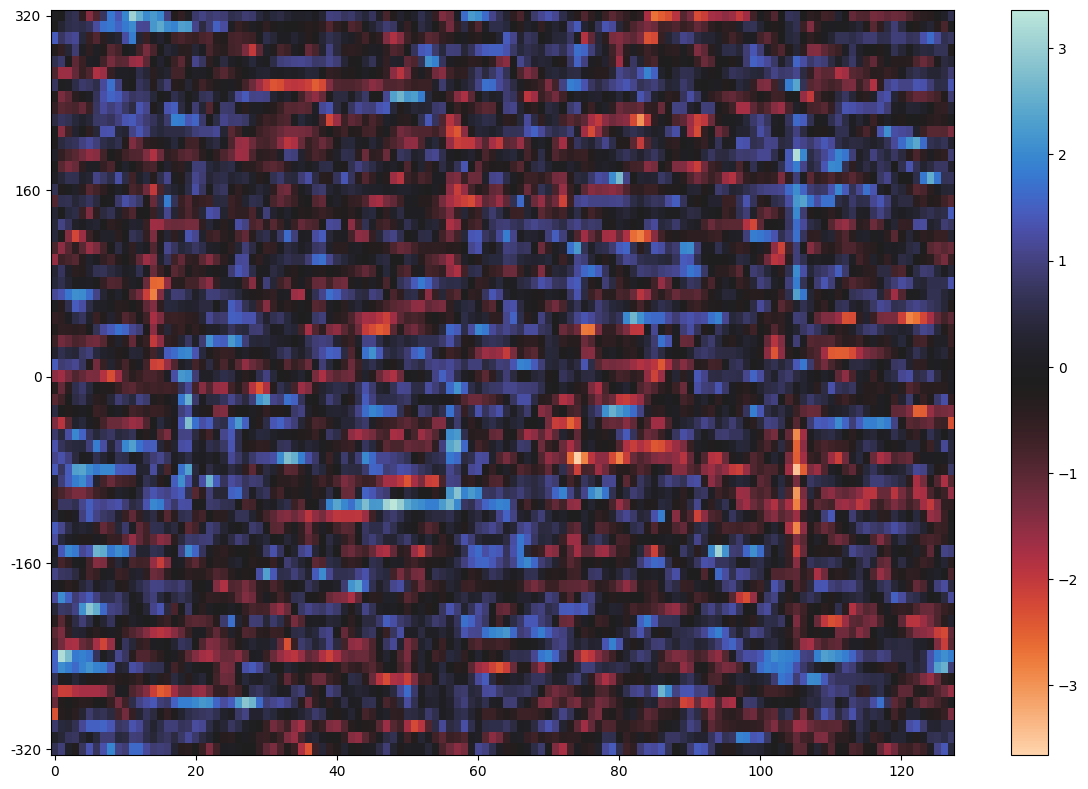

In [34]:
icefire_cmap = sns.color_palette("icefire_r", as_cmap=True)

fig, axs = plt.subplots(1,1, figsize=(12,8))
im = axs.imshow(pre_waves_close, interpolation='nearest', aspect='auto', cmap=icefire_cmap)
# axs.set_xlim([2000, 2080])
axs.set_yticks([0, 15, 31, 47, 63])
axs.set_yticklabels([320, 160, 0, -160, -320])
fig.colorbar(im)
fig.tight_layout()
# fig.savefig(os.path.join(sim_dir, sim_label, 'farthest_probes.png'), dpi=300)